# OPUS Books EN-NL data analysis

Some data analysis for deciding pre-processing steps and architectuer choices for my encoder-decoder tranlsation transformer

In [25]:
from pathlib import Path
import sys

p = Path.cwd()

while p != p.parent and not (p / "src").exists():
    p = p.parent
# Add the project root (parent of `src`) so `src` is importable as a top-level package
sys.path.insert(0, str(p))

In [26]:
from datasets import load_dataset, Dataset  # type: ignore
from typing import Dict, Any, Tuple
from torch.utils.data import random_split, Subset

from src.tokenizer import CustomTokenizer
from src.constants import END_TOKEN, PAD_TOKEN, START_TOKEN, UNKNOWN_TOKEN


def get_max_sequence_length(
    dataset: Subset,
    source_tokenizer: CustomTokenizer,
    target_tokenizer: CustomTokenizer,
) -> Tuple[int, int]:
    """Determines the maximum sequence length for source and target sentences in the dataset.

    Args:
        dataset: The dataset containing the sentences.
        source_tokenizer (CustomTokenizer): The tokenizer for the source language.
        target_tokenizer (CustomTokenizer): The tokenizer for the target language.

    Returns:
        Tuple[int, int]: A tuple containing the maximum source and target sequence lengths respectively.
    """
    max_source_length = 0
    max_target_length = 0

    for item in dataset:  # type: ignore
        source_length = len(source_tokenizer.encode(item["translation"]["en"]))  # type: ignore
        target_length = len(target_tokenizer.encode(item["translation"]["nl"]))  # type: ignore

        max_source_length = max(max_source_length, source_length)
        max_target_length = max(max_target_length, target_length)

    # Return the maximum of source and target lengths
    return max_source_length, max_target_length


def get_sentences_from_data(dataset) -> tuple[object, list[str], list[str]]:
    """Loads the OPUS Books dataset for English to Dutch translation."""
    # Load the dataset
    dataset = load_dataset("opus_books", "en-nl", split="train")

    source_sentences: list[str] = []
    target_sentences: list[str] = []

    # Iterate through the dataset and extract the English and Dutch translations
    # Each item has a "translation" field with a dictionary containing "en" and "nl" key-translations
    for item in dataset:
        # Access the translation fields directly from the item
        source_sentences.append(item["translation"]["en"])  # type: ignore
        target_sentences.append(item["translation"]["nl"])  # type: ignore
    return dataset, source_sentences, target_sentences


def load_opus_data(train_split: float = 0.7, val_split: float = 0.15, test_split: float = 0.15, deterministic: bool = False):
    """Get a train-validation-test split of the OPUS Books dataset for English to Dutch translation.

    Args:
        train_split (float, optional): The percentage of the dataset to use for training. Defaults to 0.7.
        val_split (float, optional): The percentage of the dataset to use for validation. Defaults to 0.15.
        test_split (float, optional): The percentage of the dataset to use for testing. Defaults to 0.15.
        deterministic (bool, optional): Whether to use a fixed seed for reproducibility. Defaults to False.

    Returns:
        Tuple containing (train_data, val_data, test_data)
    """
    # Validate that splits sum to 1.0
    total_split = train_split + val_split + test_split
    if not (0.99 <= total_split <= 1.01):  # Allow small floating point errors
        raise ValueError(f"Train, validation, and test splits must sum to 1.0, got {total_split}")

    # Load the dataset
    dataset: Dataset = load_dataset("opus_books", "en-nl", split="train")  # type: ignore

    seed = 42 if deterministic else None  # Use a fixed seed for reproducibility
    dataset = dataset.shuffle(seed=seed)  # Shuffle the dataset for randomness

    # Calculate the sizes for training, validation, and test sets
    dataset_length = len(dataset)  # type: ignore
    train_size = int(dataset_length * train_split)
    val_size = int(dataset_length * val_split)
    test_size = dataset_length - train_size - val_size

    train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])  # type: ignore

    return train_data, val_data, test_data


In [27]:
train, val, test = load_opus_data(deterministic=True)
print("Loaded OPUS Books dataset:")
print(f"Train size: {len(train)}")

Loaded OPUS Books dataset:
Train size: 27056


In [28]:
# Check for duplicates
seen_sentences = set()
duplicates = 0
for item in train:  # type: ignore
    source_sentence = item["translation"]["en"]  # type: ignore
    target_sentence = item["translation"]["nl"]  # type: ignore
    sentence_pair = (source_sentence, target_sentence)
    if sentence_pair in seen_sentences:
        duplicates += 1
    else:
        seen_sentences.add(sentence_pair)

print(f"Number of duplicate sentence pairs in training set: {duplicates}")

Number of duplicate sentence pairs in training set: 71


In [29]:
dutch_sentences = [item["translation"]["nl"] for item in train]  # type: ignore
english_sentences = [item["translation"]["en"] for item in train]  # type: ignore
sentences = [*english_sentences, *dutch_sentences]

tokenizer = CustomTokenizer("opus_tokenizer")
tokenizer.train(sentences)
tokenizer.save("../../../models/tokenizers/opus_tokenizer.json")

tokenizer.print_tokens(english_sentences[0])
tokenizer.print_tokens(dutch_sentences[0])

# Vocab size
print(f"Tokenizer vocabulary size: {tokenizer.vocabulary_size}")

Tokenizer file not found at opus_tokenizer. Initializing a new tokenizer.
Tokenizer saved to ../../../models/tokenizers/opus_tokenizer.json
Original text: We had started under a sky overcast but calm.
Tokens: ['We', 'had', 'started', 'under', 'a', 'sky', 'overcast', 'but', 'calm', '.']
Token IDs: [841, 187, 3809, 627, 65, 6041, 17935, 309, 2836, 17]
Original text: Toen wij vertrokken, was de lucht betrokken, maar het weder vast.
Tokens: ['Toen', 'wij', 'vertrokken', ',', 'was', 'de', 'lucht', 'betrokken', ',', 'maar', 'het', 'weder', 'vast', '.']
Token IDs: [1023, 248, 3658, 15, 168, 130, 1195, 10267, 15, 343, 167, 784, 1240, 17]
Tokenizer vocabulary size: 30000


In [30]:
from collections import Counter

tokenized_sentences = [tokenizer.encode(sentence) for sentence in sentences]
all_tokens = sorted([token for sentence in tokenized_sentences for token in sentence])

counter = Counter(all_tokens)
most_common_tokens = counter.most_common(10)

print("Most common tokens and their frequencies:")
for token, freq in most_common_tokens:
    print(f"Token: {tokenizer.decode([token])}, Token ID: {token}, Frequency: {freq}")

Most common tokens and their frequencies:
Token: ,, Token ID: 15, Frequency: 96624
Token: ., Token ID: 17, Frequency: 43224
Token: the, Token ID: 138, Frequency: 30322
Token: de, Token ID: 130, Frequency: 19888
Token: of, Token ID: 152, Frequency: 18558
Token: ", Token ID: 5, Frequency: 17354
Token: to, Token ID: 144, Frequency: 16722
Token: in, Token ID: 128, Frequency: 16671
Token: and, Token ID: 147, Frequency: 16564
Token: en, Token ID: 124, Frequency: 15731


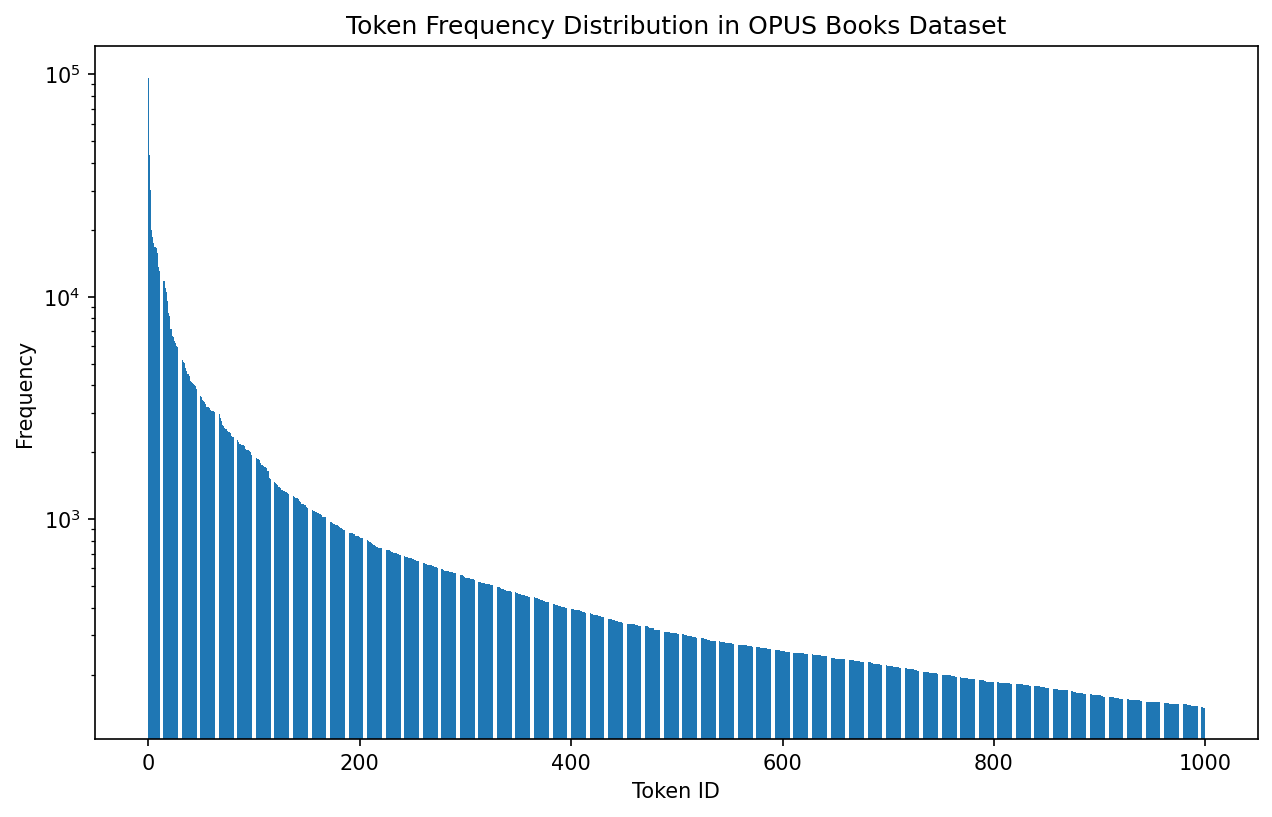

In [31]:
import matplotlib.pyplot as plt
# Plot token frequency in sentences
plt.figure(figsize=(10, 6), dpi=150)
plt.bar([i for i in range(1000)], [x[1] for x in counter.most_common(1000)])
plt.title("Token Frequency Distribution in OPUS Books Dataset")
plt.xlabel("Token ID")
plt.ylabel("Frequency")
plt.yscale("log")
plt.show()

## Source vs. Target Sentence Lengths in Tokens

Number of Dutch sentences: 27056
Number of English sentences: 27056
Maximum Dutch sentence length (in tokens): 300
Maximum English sentence length (in tokens): 716
Minimum Dutch sentence length (in tokens): 2
Minimum English sentence length (in tokens): 1
Average Dutch sentence length (in tokens): 26.69
Average English sentence length (in tokens): 27.09
90th percentile Dutch sentence length (in tokens): 53
90th percentile English sentence length (in tokens): 53
95th percentile Dutch sentence length (in tokens): 68
95th percentile English sentence length (in tokens): 70


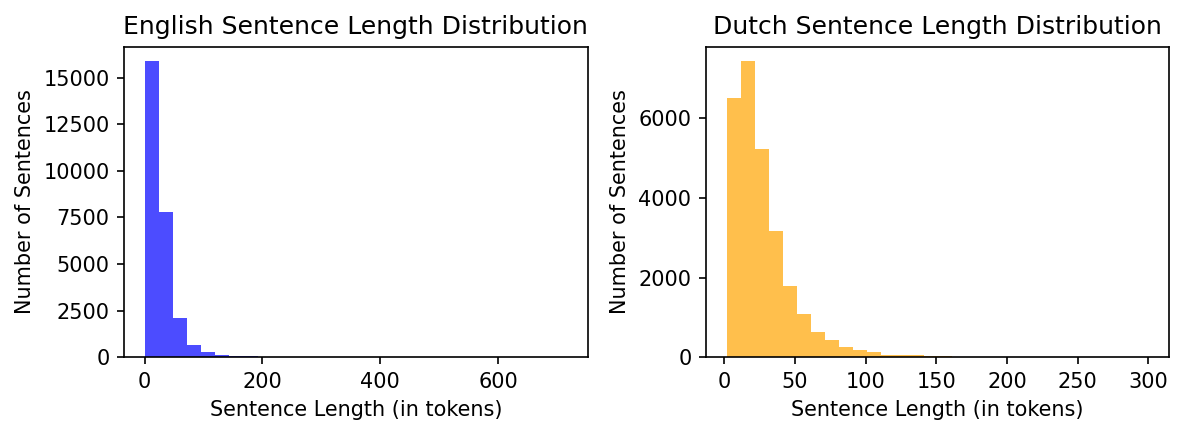

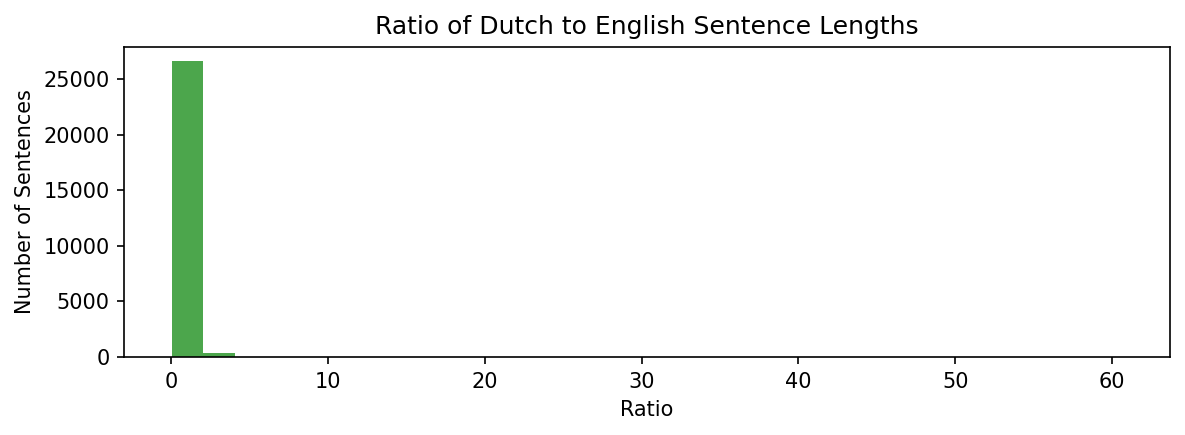

Minimum Dutch to English length ratio: 0.04
Maximum Dutch to English length ratio: 60.67
Average Dutch to English length ratio: 1.05
90th percentile Dutch to English length ratio: 1.33
95th percentile Dutch to English length ratio: 1.53


In [32]:
# Both lists are in same order
tokenized_dutch = [tokenizer.encode(sentence) for sentence in dutch_sentences]
tokenized_english = [tokenizer.encode(sentence) for sentence in english_sentences]

max_dutch_length = max(len(sentence) for sentence in tokenized_dutch)
max_english_length = max(len(sentence) for sentence in tokenized_english)
min_dutch_length = min(len(sentence) for sentence in tokenized_dutch)
min_english_length = min(len(sentence) for sentence in tokenized_english)

print(f"Number of Dutch sentences: {len(tokenized_dutch)}")
print(f"Number of English sentences: {len(tokenized_english)}")
tokenized_pairs = list(zip(tokenized_english, tokenized_dutch))

print(f"Maximum Dutch sentence length (in tokens): {max_dutch_length}")
print(f"Maximum English sentence length (in tokens): {max_english_length}")
print(f"Minimum Dutch sentence length (in tokens): {min_dutch_length}")
print(f"Minimum English sentence length (in tokens): {min_english_length}")

# Two subplots next to each other showing distribution of sentence lengths per language
avg_dutch_length = sum(len(sentence) for sentence in tokenized_dutch) / len(tokenized_dutch)
avg_english_length = sum(len(sentence) for sentence in tokenized_english) / len(tokenized_english)
print(f"Average Dutch sentence length (in tokens): {avg_dutch_length:.2f}")
print(f"Average English sentence length (in tokens): {avg_english_length:.2f}")
p90_dutch_length = sorted(len(sentence) for sentence in tokenized_dutch)[int(0.9 * len(tokenized_dutch))]
p90_english_length = sorted(len(sentence) for sentence in tokenized_english)[int(0.9 * len(tokenized_english))]
print(f"90th percentile Dutch sentence length (in tokens): {p90_dutch_length}")
print(f"90th percentile English sentence length (in tokens): {p90_english_length}")
p95_dutch_length = sorted(len(sentence) for sentence in tokenized_dutch)[int(0.95 * len(tokenized_dutch))]
p95_english_length = sorted(len(sentence) for sentence in tokenized_english)[int(0.95 * len(tokenized_english))]
print(f"95th percentile Dutch sentence length (in tokens): {p95_dutch_length}")
print(f"95th percentile English sentence length (in tokens): {p95_english_length}")


plt.figure(figsize=(8, 3), dpi=150)
plt.subplot(1, 2, 1)
plt.hist([len(sentence) for sentence in tokenized_english], bins=30, color='blue', alpha=0.7)
plt.title("English Sentence Length Distribution")
plt.xlabel("Sentence Length (in tokens)")
plt.ylabel("Number of Sentences")
plt.subplot(1, 2, 2)
plt.hist([len(sentence) for sentence in tokenized_dutch], bins=30, color='orange', alpha=0.7)
plt.title("Dutch Sentence Length Distribution")
plt.xlabel("Sentence Length (in tokens)")
plt.ylabel("Number of Sentences")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3), dpi=150)
# Plot ratio of Dutch to English sentence lengths
length_ratios = [len(dutch) / len(english) if len(english) > 0 else 0 for english, dutch in tokenized_pairs]
plt.hist(length_ratios, bins=30, color='green', alpha=0.7)
plt.title("Ratio of Dutch to English Sentence Lengths")
plt.xlabel("Ratio")
plt.ylabel("Number of Sentences")
plt.tight_layout()
plt.show()

min_ratio = min(length_ratios)
max_ratio = max(length_ratios)
avg_ratio = sum(length_ratios) / len(length_ratios)
p90_ratio = sorted(length_ratios)[int(0.9 * len(length_ratios))]
p95_ratio = sorted(length_ratios)[int(0.95 * len(length_ratios))]
print(f"Minimum Dutch to English length ratio: {min_ratio:.2f}")
print(f"Maximum Dutch to English length ratio: {max_ratio:.2f}")
print(f"Average Dutch to English length ratio: {avg_ratio:.2f}")
print(f"90th percentile Dutch to English length ratio: {p90_ratio:.2f}")
print(f"95th percentile Dutch to English length ratio: {p95_ratio:.2f}")

# Vocab coverage on test and validation sets

In [33]:
# Tokenize all sentences
tokenized_dutch_validation = [tokenizer.encode(item["translation"]["nl"]) for item in val]  # type: ignore
tokenized_english_validation = [tokenizer.encode(item["translation"]["en"]) for item in val]  # type: ignore
tokenized_dutch_test = [tokenizer.encode(item["translation"]["nl"]) for item in test]  # type: ignore
tokenized_english_test = [tokenizer.encode(item["translation"]["en"]) for item in test]  # type: ignore

# Check percentage of <UNK> tokens in validation and test sets
def calculate_unk_percentage(tokenized_sentences: list[list[int]], unk_token_id: int) -> float:
    total_tokens = sum(len(sentence) for sentence in tokenized_sentences)
    unk_tokens = sum(sentence.count(unk_token_id) for sentence in tokenized_sentences)
    return (unk_tokens / total_tokens) * 100 if total_tokens > 0 else 0.0

unk_token_id = tokenizer.token_to_id(UNKNOWN_TOKEN)
val_unk_percentage_english = calculate_unk_percentage(tokenized_english_validation, unk_token_id)
val_unk_percentage_dutch = calculate_unk_percentage(tokenized_dutch_validation, unk_token_id)
test_unk_percentage_english = calculate_unk_percentage(tokenized_english_test, unk_token_id)
test_unk_percentage_dutch = calculate_unk_percentage(tokenized_dutch_test, unk_token_id)
print(f"Validation set <UNK> token percentage (English): {val_unk_percentage_english:.4f}%")
print(f"Validation set <UNK> token percentage (Dutch): {val_unk_percentage_dutch:.4f}%")
print(f"Test set <UNK> token percentage (English): {test_unk_percentage_english:.4f}%")
print(f"Test set <UNK> token percentage (Dutch): {test_unk_percentage_dutch:.4f}%")

Validation set <UNK> token percentage (English): 0.0000%
Validation set <UNK> token percentage (Dutch): 0.0000%
Test set <UNK> token percentage (English): 0.0000%
Test set <UNK> token percentage (Dutch): 0.0000%
